In [ ]:
# COMP541 organized folder path helper
from pathlib import Path
import os

def _comp541_phase_dir():
    cwd = Path.cwd().resolve()
    if cwd.name.lower() == 'code':
        return cwd.parent
    if (cwd / 'Input').exists() and (cwd / 'Output').exists():
        return cwd
    if (cwd.parent / 'Input').exists() and (cwd.parent / 'Output').exists():
        return cwd.parent
    # Fallback for the intended layout: notebook/script is inside a Code folder.
    return cwd.parent if cwd.name.lower() == 'code' else cwd

PHASE_DIR = _comp541_phase_dir()
INPUT_DIR = PHASE_DIR / 'Input'
OUTPUT_DIR = PHASE_DIR / 'Output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('INPUT_DIR :', INPUT_DIR.resolve())
print('OUTPUT_DIR:', OUTPUT_DIR.resolve())


In [24]:
# ============================================================
# COMP 541 Project
# Accommodation Data Collection using Inside Airbnb
# Jeffrey
# =======
import re
import time
import json
from pathlib import Path
from urllib.request import Request, urlopen
from urllib.parse import urlparse, urlsplit, urlunsplit, quote
from urllib.error import HTTPError, URLError

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INSIDE_AIRBNB_URL = "https://insideairbnb.com/get-the-data/"

# For testing, set this to 5 or 10. For the full project, use None. Already passed testing phase.
MAX_AREAS = None

# Keep a small delay so the server is not hit too quickly.
DOWNLOAD_DELAY_SECONDS = 1

# OUTPUT_DIR is defined by the COMP541 organized folder path helper
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output folder:", OUTPUT_DIR.resolve())


Output folder: /content/inside_airbnb_outputs


In [2]:
def slug_to_name(slug):
    """Convert URL slugs like 'new-york-city' into 'New York City'."""
    if pd.isna(slug) or slug is None:
        return None
    return str(slug).replace("-", " ").title()


def encode_url(url):
    """
    Encode non-ASCII characters in URL paths/queries so pandas can read them.

    This fixes errors such as:
    'ascii' codec can't encode character ...
    """
    parts = urlsplit(url)
    encoded_path = quote(parts.path, safe="/:%")
    encoded_query = quote(parts.query, safe="=&%")
    return urlunsplit(
        (
            parts.scheme,
            parts.netloc,
            encoded_path,
            encoded_query,
            parts.fragment
        )
    )


def get_page_html(url):
    """Read the public Inside Airbnb data page using urllib only."""
    req = Request(
        url,
        headers={
            "User-Agent": "Mozilla/5.0 (compatible; academic project data collection)"
        }
    )

    with urlopen(req, timeout=60) as response:
        html = response.read().decode("utf-8", errors="ignore")

    return html


def extract_listing_links(html):
    """
    Extract all Inside Airbnb summary listings.csv links from HTML.

    These links are under /visualisations/listings.csv.
    """
    listing_links = re.findall(
        r'https://data\.insideairbnb\.com/[^"\']+/visualisations/listings\.csv',
        html
    )

    return sorted(set(listing_links))


def parse_inside_airbnb_url(url):
    """
    Parse Inside Airbnb data URLs.

    Example:
    https://data.insideairbnb.com/united-states/ca/los-angeles/2025-12-04/visualisations/listings.csv

    Returns:
    country_slug, region_slug, area_slug, location_path, data_date, download_url
    """
    path_parts = urlparse(url).path.strip("/").split("/")

    date_index = None
    for i, part in enumerate(path_parts):
        if re.match(r"\d{4}-\d{2}-\d{2}", part):
            date_index = i
            break

    if date_index is None:
        return None

    location_parts = path_parts[:date_index]
    data_date = path_parts[date_index]

    country_slug = location_parts[0] if len(location_parts) >= 1 else None

    # City-level files often look like country / region / area / date.
    # Country-level files can have fewer location parts.
    region_slug = location_parts[1] if len(location_parts) >= 3 else None
    area_slug = location_parts[-1] if len(location_parts) >= 1 else None

    return {
        "country_slug": country_slug,
        "region_slug": region_slug,
        "area_slug": area_slug,
        "location_path": "/".join(location_parts),
        "data_date": data_date,
        "download_url": url
    }


def safe_read_csv(url):
    """Read a CSV from a URL after encoding non-ASCII characters."""
    safe_url = encode_url(url)
    return pd.read_csv(safe_url)


def remove_price_outliers_by_group(group):
    """Remove the top 1 percent of prices within each destination/location group."""
    cap = group["price"].quantile(0.99)
    return group[group["price"] <= cap]


def save_plot(filename):
    """Save and show the current matplotlib plot."""
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()

In [3]:
print("Reading Inside Airbnb data page...")

html = get_page_html(INSIDE_AIRBNB_URL)
listing_links = extract_listing_links(html)

print("Number of Inside Airbnb listings.csv links found:", len(listing_links))

if len(listing_links) == 0:
    raise ValueError("No listings.csv links found. Check the Inside Airbnb page structure.")

listing_links[:5]

Reading Inside Airbnb data page...
Number of Inside Airbnb listings.csv links found: 119


['https://data.insideairbnb.com/argentina/ciudad-autónoma-de-buenos-aires/buenos-aires/2026-01-25/visualisations/listings.csv',
 'https://data.insideairbnb.com/australia/nsw/mid-north-coast/2025-11-12/visualisations/listings.csv',
 'https://data.insideairbnb.com/australia/nsw/northern-rivers/2025-09-22/visualisations/listings.csv',
 'https://data.insideairbnb.com/australia/nsw/sydney/2025-09-12/visualisations/listings.csv',
 'https://data.insideairbnb.com/australia/qld/brisbane/2026-01-16/visualisations/listings.csv']

In [4]:
metadata_rows = []

for url in listing_links:
    parsed = parse_inside_airbnb_url(url)
    if parsed is not None:
        metadata_rows.append(parsed)

links_df = pd.DataFrame(metadata_rows)

links_df["data_date"] = pd.to_datetime(links_df["data_date"], errors="coerce")
links_df["destination"] = links_df["area_slug"].apply(slug_to_name)
links_df["country"] = links_df["country_slug"].apply(slug_to_name)
links_df["region"] = links_df["region_slug"].apply(slug_to_name)

selected_links = (
    links_df
    .sort_values(["location_path", "data_date"], ascending=[True, False])
    .drop_duplicates(subset=["location_path"], keep="first")
    .copy()
)

selected_links = selected_links[
    [
        "destination",
        "country",
        "region",
        "country_slug",
        "region_slug",
        "area_slug",
        "location_path",
        "data_date",
        "download_url"
    ]
].sort_values(["country", "region", "destination"])

selected_links.to_csv(OUTPUT_DIR / "inside_airbnb_selected_source_links.csv", index=False)

print("Total available global areas selected:", selected_links.shape[0])

if selected_links.shape[0] < 20:
    print("WARNING: selected_links has fewer than 20 areas. Make sure old filtered cells are not being used.")

selected_links.head(20)

Total available global areas selected: 119


,destination,country,region,country_slug,region_slug,area_slug,location_path,data_date,download_url
0,Buenos Aires,Argentina,Ciudad Autónoma De Buenos Aires,argentina,ciudad-autónoma-de-buenos-aires,buenos-aires,argentina/ciudad-autónoma-de-buenos-aires/buen...,2026-01-25,https://data.insideairbnb.com/argentina/ciudad...
1,Mid North Coast,Australia,Nsw,australia,nsw,mid-north-coast,australia/nsw/mid-north-coast,2025-11-12,https://data.insideairbnb.com/australia/nsw/mi...
2,Northern Rivers,Australia,Nsw,australia,nsw,northern-rivers,australia/nsw/northern-rivers,2025-09-22,https://data.insideairbnb.com/australia/nsw/no...
3,Sydney,Australia,Nsw,australia,nsw,sydney,australia/nsw/sydney,2025-09-12,https://data.insideairbnb.com/australia/nsw/sy...
4,Brisbane,Australia,Qld,australia,qld,brisbane,australia/qld/brisbane,2026-01-16,https://data.insideairbnb.com/australia/qld/br...
5,Sunshine Coast,Australia,Qld,australia,qld,sunshine-coast,australia/qld/sunshine-coast,2025-09-30,https://data.insideairbnb.com/australia/qld/su...
6,Barossa Valley,Australia,Sa,australia,sa,barossa-valley,australia/sa/barossa-valley,2025-09-27,https://data.insideairbnb.com/australia/sa/bar...
7,Tasmania,Australia,Tas,australia,tas,tasmania,australia/tas/tasmania,2025-09-11,https://data.insideairbnb.com/australia/tas/ta...
8,Barwon South West Vic,Australia,Vic,australia,vic,barwon-south-west-vic,australia/vic/barwon-south-west-vic,2025-09-28,https://data.insideairbnb.com/australia/vic/ba...
9,Melbourne,Australia,Vic,australia,vic,melbourne,australia/vic/melbourne,2025-09-12,https://data.insideairbnb.com/australia/vic/me...


In [5]:
all_listings = []
failed_downloads = []

download_links = selected_links.copy()

if MAX_AREAS is not None:
    download_links = download_links.head(MAX_AREAS)

print("Areas to download:", download_links.shape[0])

for i, (_, row) in enumerate(download_links.iterrows(), start=1):
    destination = row["destination"]
    country = row["country"]
    download_url = row["download_url"]

    print(f"[{i}/{download_links.shape[0]}] Downloading {destination}, {country}")

    try:
        df = safe_read_csv(download_url)

        df["destination"] = destination
        df["area_slug"] = row["area_slug"]
        df["location_path"] = row["location_path"]
        df["country"] = row["country"]
        df["region"] = row["region"]
        df["country_slug"] = row["country_slug"]
        df["region_slug"] = row["region_slug"]
        df["inside_airbnb_data_date"] = row["data_date"]
        df["source_url"] = download_url

        all_listings.append(df)

        time.sleep(DOWNLOAD_DELAY_SECONDS)

    except Exception as e:
        failed_downloads.append({
            "destination": destination,
            "country": country,
            "download_url": download_url,
            "error": str(e)
        })
        print("FAILED:", destination, country, e)

if len(all_listings) == 0:
    raise ValueError("No files downloaded. Check the URLs or internet connection.")

airbnb_raw = pd.concat(all_listings, ignore_index=True)
failed_downloads_df = pd.DataFrame(failed_downloads)

print("Raw combined shape:", airbnb_raw.shape)
print("Failed downloads:", failed_downloads_df.shape[0])

airbnb_raw.to_csv(OUTPUT_DIR / "inside_airbnb_raw_combined.csv", index=False)
failed_downloads_df.to_csv(OUTPUT_DIR / "inside_airbnb_failed_downloads.csv", index=False)

airbnb_raw.head()

Areas to download: 119
[1/119] Downloading Buenos Aires, Argentina
[2/119] Downloading Mid North Coast, Australia
[3/119] Downloading Northern Rivers, Australia
[4/119] Downloading Sydney, Australia
[5/119] Downloading Brisbane, Australia
[6/119] Downloading Sunshine Coast, Australia
[7/119] Downloading Barossa Valley, Australia
[8/119] Downloading Tasmania, Australia
[9/119] Downloading Barwon South West Vic, Australia
[10/119] Downloading Melbourne, Australia
[11/119] Downloading Mornington Peninsula, Australia
[12/119] Downloading Western Australia, Australia
[13/119] Downloading Vienna, Austria
[14/119] Downloading Brussels, Belgium
[15/119] Downloading Antwerp, Belgium
[16/119] Downloading Ghent, Belgium
[17/119] Downloading Belize, Belize
[18/119] Downloading Rio De Janeiro, Brazil
[19/119] Downloading Vancouver, Canada
[20/119] Downloading Victoria, Canada
[21/119] Downloading Winnipeg, Canada
[22/119] Downloading New Brunswick, Canada
[23/119] Downloading Ottawa, Canada
[24/119

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,...,area_slug,location_path,country,region,country_slug,region_slug,inside_airbnb_data_date,source_url,availability_eoy,number_of_reviews_ly
0,42610838,"Puerto Madero a 3 cuadras, centro, bello , tea...",224049389,1.469189e+18,Gabriela,NaN,San Nicolas,-34.599976,-58.374195,Entire home/apt,...,buenos-aires,argentina/ciudad-autónoma-de-buenos-aires/buen...,Argentina,Ciudad Autónoma De Buenos Aires,argentina,ciudad-autónoma-de-buenos-aires,2026-01-25,https://data.insideairbnb.com/argentina/ciudad...,NaN,NaN
1,1305876403852901802,Apart estudio en Microcentro,25649070,1.465348e+18,Federico,NaN,San Nicolas,-34.600382,-58.372692,Entire home/apt,...,buenos-aires,argentina/ciudad-autónoma-de-buenos-aires/buen...,Argentina,Ciudad Autónoma De Buenos Aires,argentina,ciudad-autónoma-de-buenos-aires,2026-01-25,https://data.insideairbnb.com/argentina/ciudad...,NaN,NaN
2,1542233033640525302,"Departamento en Buenos Aires, abasto shopping",153014015,1.468500e+18,Marco,NaN,Balvanera,-34.603295,-58.409527,Entire home/apt,...,buenos-aires,argentina/ciudad-autónoma-de-buenos-aires/buen...,Argentina,Ciudad Autónoma De Buenos Aires,argentina,ciudad-autónoma-de-buenos-aires,2026-01-25,https://data.insideairbnb.com/argentina/ciudad...,NaN,NaN
3,1004530078359434134,Departamento en Recoleta,1409800,1.462518e+18,Marian,NaN,Balvanera,-34.599230,-58.407060,Entire home/apt,...,buenos-aires,argentina/ciudad-autónoma-de-buenos-aires/buen...,Argentina,Ciudad Autónoma De Buenos Aires,argentina,ciudad-autónoma-de-buenos-aires,2026-01-25,https://data.insideairbnb.com/argentina/ciudad...,NaN,NaN
4,800145927121871422,Coqueto para 4 personas,467965425,1.470110e+18,Maria Del Carmen,NaN,Almagro,-34.599767,-58.426499,Entire home/apt,...,buenos-aires,argentina/ciudad-autónoma-de-buenos-aires/buen...,Argentina,Ciudad Autónoma De Buenos Aires,argentina,ciudad-autónoma-de-buenos-aires,2026-01-25,https://data.insideairbnb.com/argentina/ciudad...,NaN,NaN


In [6]:
print("Failed downloads:", failed_downloads_df.shape[0])
failed_downloads_df.head(20)

Failed downloads: 0


""


In [7]:
print("Raw data shape:", airbnb_raw.shape)

print("\nColumns:")
for col in airbnb_raw.columns:
    print(col)

Raw data shape: (1574273, 30)

Columns:
id
name
host_id
host_profile_id
host_name
neighbourhood_group
neighbourhood
latitude
longitude
room_type
price
minimum_nights
number_of_reviews
last_review
reviews_per_month
calculated_host_listings_count
availability_365
number_of_reviews_ltm
license
destination
area_slug
location_path
country
region
country_slug
region_slug
inside_airbnb_data_date
source_url
availability_eoy
number_of_reviews_ly


In [8]:
keep_cols = [
    "id",
    "name",
    "host_id",
    "host_name",
    "neighbourhood",
    "latitude",
    "longitude",
    "room_type",
    "price",
    "minimum_nights",
    "number_of_reviews",
    "last_review",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "number_of_reviews_ltm",
    "license",
    "destination",
    "area_slug",
    "location_path",
    "country",
    "region",
    "country_slug",
    "region_slug",
    "inside_airbnb_data_date",
    "source_url"
]

available_cols = [col for col in keep_cols if col in airbnb_raw.columns]
airbnb_clean = airbnb_raw[available_cols].copy()

if "id" in airbnb_clean.columns:
    airbnb_clean = airbnb_clean.rename(columns={"id": "listing_id"})

airbnb_clean["price"] = (
    airbnb_clean["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

airbnb_clean["price"] = pd.to_numeric(airbnb_clean["price"], errors="coerce")

numeric_cols = [
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "number_of_reviews_ltm",
    "latitude",
    "longitude"
]

for col in numeric_cols:
    if col in airbnb_clean.columns:
        airbnb_clean[col] = pd.to_numeric(airbnb_clean[col], errors="coerce")

if "last_review" in airbnb_clean.columns:
    airbnb_clean["last_review"] = pd.to_datetime(airbnb_clean["last_review"], errors="coerce")

before_rows = airbnb_clean.shape[0]

airbnb_clean = airbnb_clean.dropna(subset=["price"])
airbnb_clean = airbnb_clean[airbnb_clean["price"] > 0].copy()

after_price_clean_rows = airbnb_clean.shape[0]

group_key = "location_path" if "location_path" in airbnb_clean.columns else "destination"

airbnb_clean = (
    airbnb_clean
    .groupby(group_key, group_keys=False)
    .apply(remove_price_outliers_by_group)
    .reset_index(drop=True)
)

after_outlier_rows = airbnb_clean.shape[0]

print("Rows before cleaning:", before_rows)
print("Rows after missing/invalid price removal:", after_price_clean_rows)
print("Rows after outlier removal:", after_outlier_rows)
print("Cleaned shape:", airbnb_clean.shape)

airbnb_clean.to_csv(OUTPUT_DIR / "inside_airbnb_accommodation_clean.csv", index=False)

airbnb_clean.head()

/tmp/ipykernel_7347/3782378616.py:76: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(remove_price_outliers_by_group)


Rows before cleaning: 1574273
Rows after missing/invalid price removal: 948215
Rows after outlier removal: 939408
Cleaned shape: (939408, 26)


,listing_id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,...,license,destination,area_slug,location_path,country,region,country_slug,region_slug,inside_airbnb_data_date,source_url
0,71825,River Room Bellingen Treehouse,369209,Kirsty,Bellingen,-30.36893,152.88534,Entire home/apt,270.0,2.0,...,PID-STRA-6155,Mid North Coast,mid-north-coast,australia/nsw/mid-north-coast,Australia,Nsw,australia,nsw,2025-11-12,https://data.insideairbnb.com/australia/nsw/mi...
1,325891,Kiwarrak Country Retreat-The Arbour,1666893,Tara And Meg,Mid-Coast,-31.96903,152.50838,Entire home/apt,236.0,2.0,...,PID-STRA-9140-2,Mid North Coast,mid-north-coast,australia/nsw/mid-north-coast,Australia,Nsw,australia,nsw,2025-11-12,https://data.insideairbnb.com/australia/nsw/mi...
2,325913,Kiwarrak Country Retreat -The Bower,1666893,Tara And Meg,Mid-Coast,-31.96723,152.50814,Entire home/apt,181.0,2.0,...,PID-STRA-9140-2,Mid North Coast,mid-north-coast,australia/nsw/mid-north-coast,Australia,Nsw,australia,nsw,2025-11-12,https://data.insideairbnb.com/australia/nsw/mi...
3,534462,Tree Tops Scott’s Head sleeps 8 & 100m to beach.,2626160,Angus,Nambucca Valley,-30.74711,152.99480,Entire home/apt,316.0,2.0,...,PID-STRA-86067,Mid North Coast,mid-north-coast,australia/nsw/mid-north-coast,Australia,Nsw,australia,nsw,2025-11-12,https://data.insideairbnb.com/australia/nsw/mi...
4,737655,Lakeview Cottage - Between the ocean and the l...,359599,Ken,Mid-Coast,-32.24756,152.51427,Entire home/apt,195.0,2.0,...,PID-STRA-12211,Mid North Coast,mid-north-coast,australia/nsw/mid-north-coast,Australia,Nsw,australia,nsw,2025-11-12,https://data.insideairbnb.com/australia/nsw/mi...


In [9]:
quality_group_cols = ["location_path", "destination"]

for col in ["country", "region"]:
    if col in airbnb_clean.columns:
        quality_group_cols.append(col)

quality_summary = (
    airbnb_clean
    .groupby(quality_group_cols)
    .agg(
        listings_after_cleaning=("listing_id", "count"),
        missing_price=("price", lambda x: x.isna().sum()),
        min_price=("price", "min"),
        median_price=("price", "median"),
        max_price=("price", "max")
    )
    .reset_index()
)

sort_cols = ["country", "destination"] if "country" in quality_summary.columns else ["destination"]
quality_summary = quality_summary.sort_values(sort_cols)

quality_summary.to_csv(OUTPUT_DIR / "inside_airbnb_quality_summary.csv", index=False)

print("Quality summary shape:", quality_summary.shape)
quality_summary.head(20)

Quality summary shape: (93, 9)


,location_path,destination,country,region,listings_after_cleaning,missing_price,min_price,median_price,max_price
3,australia/sa/barossa-valley,Barossa Valley,Australia,Sa,314,0,69.0,303.5,1800.0
5,australia/vic/barwon-south-west-vic,Barwon South West Vic,Australia,Vic,6245,0,28.0,296.0,1354.0
0,australia/nsw/mid-north-coast,Mid North Coast,Australia,Nsw,4572,0,30.0,249.0,1142.0
6,australia/vic/mornington-peninsula,Mornington Peninsula,Australia,Vic,3999,0,54.0,392.0,2316.0
1,australia/nsw/northern-rivers,Northern Rivers,Australia,Nsw,5354,0,45.0,334.0,2816.0
2,australia/qld/sunshine-coast,Sunshine Coast,Australia,Qld,6395,0,16.0,351.0,2729.0
4,australia/tas/tasmania,Tasmania,Australia,Tas,5609,0,32.0,197.0,982.0
7,australia/wa/western-australia,Western Australia,Australia,Wa,11141,0,22.0,218.0,1166.0
8,austria/vienna/vienna,Vienna,Austria,Vienna,10202,0,13.0,92.0,876.0
10,belgium/vlg/antwerp,Antwerp,Belgium,Vlg,2126,0,13.0,93.0,1013.0


In [10]:
summary_group_cols = ["location_path", "destination"]

for col in ["country", "region"]:
    if col in airbnb_clean.columns:
        summary_group_cols.append(col)

agg_dict = {
    "listing_count": ("listing_id", "count"),
    "avg_airbnb_price": ("price", "mean"),
    "median_airbnb_price": ("price", "median"),
    "min_airbnb_price": ("price", "min"),
    "max_airbnb_price": ("price", "max")
}

if "minimum_nights" in airbnb_clean.columns:
    agg_dict["avg_minimum_nights"] = ("minimum_nights", "mean")

if "number_of_reviews" in airbnb_clean.columns:
    agg_dict["avg_number_of_reviews"] = ("number_of_reviews", "mean")
    agg_dict["total_reviews"] = ("number_of_reviews", "sum")

if "reviews_per_month" in airbnb_clean.columns:
    agg_dict["avg_reviews_per_month"] = ("reviews_per_month", "mean")

if "availability_365" in airbnb_clean.columns:
    agg_dict["avg_availability_365"] = ("availability_365", "mean")

airbnb_summary_global = (
    airbnb_clean
    .groupby(summary_group_cols)
    .agg(**agg_dict)
    .reset_index()
)

airbnb_summary_global["estimated_7_day_lodging_cost"] = (
    airbnb_summary_global["median_airbnb_price"] * 7
)

sort_cols = ["country", "estimated_7_day_lodging_cost"] if "country" in airbnb_summary_global.columns else ["estimated_7_day_lodging_cost"]
airbnb_summary_global = airbnb_summary_global.sort_values(sort_cols)

airbnb_summary_global.to_csv(
    OUTPUT_DIR / "inside_airbnb_global_destination_summary.csv",
    index=False
)

print("Global destination summary shape:", airbnb_summary_global.shape)

airbnb_summary_global.head(20)

Global destination summary shape: (93, 15)


,location_path,destination,country,region,listing_count,avg_airbnb_price,median_airbnb_price,min_airbnb_price,max_airbnb_price,avg_minimum_nights,avg_number_of_reviews,total_reviews,avg_reviews_per_month,avg_availability_365,estimated_7_day_lodging_cost
4,australia/tas/tasmania,Tasmania,Australia,Tas,5609,227.789446,197.0,32.0,982.0,1.911749,101.783562,570904,2.097261,228.086825,1379.0
7,australia/wa/western-australia,Western Australia,Australia,Wa,11141,255.928193,218.0,22.0,1166.0,8.639799,61.682793,687208,1.743817,222.521407,1526.0
0,australia/nsw/mid-north-coast,Mid North Coast,Australia,Nsw,4572,292.925416,249.0,30.0,1142.0,7.608486,53.765967,245818,1.315658,240.729440,1743.0
5,australia/vic/barwon-south-west-vic,Barwon South West Vic,Australia,Vic,6245,351.034107,296.0,28.0,1354.0,2.136910,62.725060,391718,1.365126,210.247878,2072.0
3,australia/sa/barossa-valley,Barossa Valley,Australia,Sa,314,365.624204,303.5,69.0,1800.0,1.722930,65.277070,20497,1.493262,267.076433,2124.5
1,australia/nsw/northern-rivers,Northern Rivers,Australia,Nsw,5354,461.583489,334.0,45.0,2816.0,8.983003,53.102167,284309,1.231715,217.916698,2338.0
2,australia/qld/sunshine-coast,Sunshine Coast,Australia,Qld,6395,453.965598,351.0,16.0,2729.0,3.079750,54.867553,350878,1.540034,206.142768,2457.0
6,australia/vic/mornington-peninsula,Mornington Peninsula,Australia,Vic,3999,500.378095,392.0,54.0,2316.0,2.585146,48.000250,191953,1.204664,245.945236,2744.0
8,austria/vienna/vienna,Vienna,Austria,Vienna,10202,116.203980,92.0,13.0,876.0,7.240933,51.842090,528893,1.824123,212.689865,644.0
9,belgium/bru/brussels,Brussels,Belgium,Bru,5014,107.771440,90.0,8.0,490.0,9.729158,57.041085,286004,2.216260,208.343638,630.0


In [11]:
if "country" in airbnb_summary_global.columns:
    country_summary = (
        airbnb_summary_global
        .groupby("country")
        .agg(
            destination_count=("destination", "count"),
            total_listings=("listing_count", "sum"),
            median_destination_price=("median_airbnb_price", "median"),
            avg_destination_price=("avg_airbnb_price", "mean"),
            median_7_day_lodging_cost=("estimated_7_day_lodging_cost", "median")
        )
        .reset_index()
        .sort_values("total_listings", ascending=False)
    )

    country_summary.to_csv(OUTPUT_DIR / "inside_airbnb_country_summary.csv", index=False)
    display(country_summary.head(25))
else:
    print("No country column found.")

,country,destination_count,total_listings,median_destination_price,avg_destination_price,median_7_day_lodging_cost
14,Italy,10,192525,122.00,224.485728,854.00
29,United States,25,143353,139.00,283.472452,973.00
28,United Kingdom,4,74906,115.50,148.575197,808.50
11,Greece,4,74427,92.00,179.366575,644.00
21,Spain,7,65760,124.00,419.471920,868.00
0,Australia,8,43629,299.75,363.653568,2098.25
4,Brazil,1,38283,315.00,528.316563,2205.00
15,Japan,1,25225,16065.00,20480.271041,112455.00
27,Turkey,1,24995,2510.00,3363.263893,17570.00
17,Mexico,1,23331,1031.00,1334.737088,7217.00


In [12]:
if "room_type" in airbnb_clean.columns:
    room_type_summary = (
        airbnb_clean
        .groupby(["location_path", "destination", "country", "region", "room_type"], dropna=False)
        .agg(
            listing_count=("listing_id", "count"),
            median_price=("price", "median"),
            avg_price=("price", "mean")
        )
        .reset_index()
        .sort_values(["destination", "listing_count"], ascending=[True, False])
    )

    room_type_overall = (
        airbnb_clean
        .groupby("room_type", dropna=False)
        .agg(
            listing_count=("listing_id", "count"),
            median_price=("price", "median"),
            avg_price=("price", "mean")
        )
        .reset_index()
        .sort_values("listing_count", ascending=False)
    )

    room_type_summary.to_csv(
        OUTPUT_DIR / "inside_airbnb_room_type_summary.csv",
        index=False
    )

    room_type_overall.to_csv(
        OUTPUT_DIR / "inside_airbnb_room_type_overall.csv",
        index=False
    )

    display(room_type_overall)
    display(room_type_summary.head(30))
else:
    room_type_summary = pd.DataFrame()
    room_type_overall = pd.DataFrame()
    print("No room_type column found.")

,room_type,listing_count,median_price,avg_price
0,Entire home/apt,756147,185.0,1617.983192
2,Private room,175472,96.0,777.159000
3,Shared room,4168,73.0,698.415547
1,Hotel room,3621,193.0,2994.647887


,location_path,destination,country,region,room_type,listing_count,median_price,avg_price
240,the-netherlands/north-holland/amsterdam,Amsterdam,The Netherlands,North Holland,Entire home/apt,4481,247.0,279.151752
242,the-netherlands/north-holland/amsterdam,Amsterdam,The Netherlands,North Holland,Private room,1271,139.0,163.267506
241,the-netherlands/north-holland/amsterdam,Amsterdam,The Netherlands,North Holland,Hotel room,33,213.0,209.303030
243,the-netherlands/north-holland/amsterdam,Amsterdam,The Netherlands,North Holland,Shared room,30,95.5,130.266667
34,belgium/vlg/antwerp,Antwerp,Belgium,Vlg,Entire home/apt,1749,97.0,125.169811
36,belgium/vlg/antwerp,Antwerp,Belgium,Vlg,Private room,367,62.0,100.346049
35,belgium/vlg/antwerp,Antwerp,Belgium,Vlg,Hotel room,7,184.0,190.428571
37,belgium/vlg/antwerp,Antwerp,Belgium,Vlg,Shared room,3,55.0,51.000000
321,united-states/nc/asheville,Asheville,United States,Nc,Entire home/apt,2282,138.0,176.821209
323,united-states/nc/asheville,Asheville,United States,Nc,Private room,210,70.5,99.885714


In [13]:
top_listing_destinations = airbnb_summary_global.nlargest(20, "listing_count")
cheapest_20_raw = airbnb_summary_global.nsmallest(20, "estimated_7_day_lodging_cost")
expensive_20_raw = airbnb_summary_global.nlargest(20, "estimated_7_day_lodging_cost")

top_listing_destinations.to_csv(
    OUTPUT_DIR / "inside_airbnb_top_20_listing_destinations.csv",
    index=False
)

cheapest_20_raw.to_csv(
    OUTPUT_DIR / "inside_airbnb_cheapest_20_destinations_raw_currency.csv",
    index=False
)

expensive_20_raw.to_csv(
    OUTPUT_DIR / "inside_airbnb_expensive_20_destinations_raw_currency.csv",
    index=False
)

view_cols = [
    "location_path",
    "destination",
    "country",
    "region",
    "listing_count",
    "median_airbnb_price",
    "avg_airbnb_price",
    "estimated_7_day_lodging_cost",
    "avg_number_of_reviews",
    "avg_reviews_per_month",
    "avg_availability_365"
]

view_cols = [col for col in view_cols if col in airbnb_summary_global.columns]

view_table = (
    airbnb_summary_global[view_cols]
    .sort_values("listing_count", ascending=False)
)

view_table.to_csv(OUTPUT_DIR / "inside_airbnb_view_table.csv", index=False)

print("Top listing destinations")
display(top_listing_destinations)

print("Cheapest destinations, raw local currency. Do not compare globally until currency conversion.")
display(cheapest_20_raw)

print("Most expensive destinations, raw local currency. Do not compare globally until currency conversion.")
display(expensive_20_raw)

Top listing destinations


,location_path,destination,country,region,listing_count,avg_airbnb_price,median_airbnb_price,min_airbnb_price,max_airbnb_price,avg_minimum_nights,avg_number_of_reviews,total_reviews,avg_reviews_per_month,avg_availability_365,estimated_7_day_lodging_cost
66,united-kingdom/england/london,London,United Kingdom,England,61350,175.162901,134.0,7.0,1100.0,4.988655,27.140163,1665049,1.287409,214.145672,938.0
39,italy/sicilia/sicily,Sicily,Italy,Sicilia,51417,257.715405,87.0,8.0,9858.0,6.973744,22.737694,1169104,0.827193,252.769862,609.0
38,italy/puglia/puglia,Puglia,Italy,Puglia,42550,273.512385,90.0,2.0,9429.0,5.991398,13.641222,580434,0.660673,229.560658,630.0
13,brazil/rj/rio-de-janeiro,Rio De Janeiro,Brazil,Rj,38283,528.316563,315.0,30.0,7125.0,3.425228,27.707259,1060717,1.270251,206.128595,2205.0
35,italy/lazio/rome,Rome,Italy,Lazio,33228,165.777597,132.0,8.0,1005.0,4.254484,62.362375,2072177,1.845836,230.264145,924.0
76,united-states/hi/hawaii,Hawaii,United States,Hi,33029,799.433074,232.0,9.0,40000.0,7.325260,42.257228,1395714,1.134901,230.053226,1624.0
30,greece/south-aegean/south-aegean,South Aegean,Greece,South Aegean,31641,366.528144,142.0,10.0,9000.0,3.362378,25.084763,793707,0.742146,180.531620,994.0
43,japan/kantō/tokyo,Tokyo,Japan,Kantō,25225,20480.271041,16065.0,1500.0,148624.0,4.957225,37.223984,938975,1.725467,178.503389,112455.0
63,turkey/marmara/istanbul,Istanbul,Turkey,Marmara,24995,3363.263893,2510.0,80.0,25060.0,48.530546,19.979436,499386,1.235514,298.445769,17570.0
29,greece/crete/crete,Crete,Greece,Crete,24133,180.070194,107.0,15.0,2500.0,4.808354,22.477562,542451,0.693270,202.889032,749.0


Cheapest destinations, raw local currency. Do not compare globally until currency conversion.


,location_path,destination,country,region,listing_count,avg_airbnb_price,median_airbnb_price,min_airbnb_price,max_airbnb_price,avg_minimum_nights,avg_number_of_reviews,total_reviews,avg_reviews_per_month,avg_availability_365,estimated_7_day_lodging_cost
44,latvia/riga/riga,Riga,Latvia,Riga,2702,59.619911,49.0,10.0,267.0,3.037010,53.605848,144843,1.913012,217.734641,343.0
28,greece/central-macedonia/thessaloniki,Thessaloniki,Greece,Central Macedonia,4275,68.095673,57.0,10.0,389.0,2.420117,45.146199,193000,1.501786,248.051228,399.0
27,greece/attica/athens,Athens,Greece,Attica,14378,102.772291,77.0,9.0,600.0,2.435387,58.303797,838292,1.791667,259.262484,539.0
22,france/auvergne-rhone-alpes/lyon,Lyon,France,Auvergne Rhone Alpes,5203,97.273880,78.0,12.0,457.0,10.240246,69.255814,360338,1.957697,197.567557,546.0
23,france/nouvelle-aquitaine/bordeaux,Bordeaux,France,Nouvelle Aquitaine,7700,104.553766,78.0,9.0,538.0,9.765714,51.010779,392783,1.640048,209.627662,546.0
33,italy/campania/naples,Naples,Italy,Campania,9738,108.217704,87.0,13.0,900.0,5.586979,43.243479,421105,1.479413,245.534915,609.0
39,italy/sicilia/sicily,Sicily,Italy,Sicilia,51417,257.715405,87.0,8.0,9858.0,6.973744,22.737694,1169104,0.827193,252.769862,609.0
36,italy/lombardia/bergamo,Bergamo,Italy,Lombardia,3488,106.757454,88.0,10.0,1000.0,4.676319,39.224771,136816,1.427322,232.513188,616.0
65,united-kingdom/england/greater-manchester,Greater Manchester,United Kingdom,England,6496,103.680111,89.0,16.0,696.0,4.100985,36.784483,238952,1.779119,240.402709,623.0
9,belgium/bru/brussels,Brussels,Belgium,Bru,5014,107.771440,90.0,8.0,490.0,9.729158,57.041085,286004,2.216260,208.343638,630.0


Most expensive destinations, raw local currency. Do not compare globally until currency conversion.


,location_path,destination,country,region,listing_count,avg_airbnb_price,median_airbnb_price,min_airbnb_price,max_airbnb_price,avg_minimum_nights,avg_number_of_reviews,total_reviews,avg_reviews_per_month,avg_availability_365,estimated_7_day_lodging_cost
31,hungary/közép-magyarország/budapest,Budapest,Hungary,Közép Magyarország,11463,29690.635174,21753.0,3914.0,242858.0,3.213208,89.075460,1021072,2.297485,189.143505,152271.0
43,japan/kantō/tokyo,Tokyo,Japan,Kantō,25225,20480.271041,16065.0,1500.0,148624.0,4.957225,37.223984,938975,1.725467,178.503389,112455.0
63,turkey/marmara/istanbul,Istanbul,Turkey,Marmara,24995,3363.263893,2510.0,80.0,25060.0,48.530546,19.979436,499386,1.235514,298.445769,17570.0
20,czech-republic/prague/prague,Prague,Czech Republic,Prague,9403,2711.601085,2136.0,223.0,21818.0,3.383388,85.305328,802126,2.452255,198.427417,14952.0
59,taiwan/northern-taiwan/taipei,Taipei,Taiwan,Northern Taiwan,5467,2525.827693,2000.0,5.0,14123.0,10.563014,35.813975,195795,1.460927,195.977867,14000.0
48,south-africa/wc/cape-town,Cape Town,South Africa,Wc,22251,2704.246146,1509.0,161.0,28286.0,3.933846,27.509640,612117,0.934583,231.643836,10563.0
60,thailand/central-thailand/bangkok,Bangkok,Thailand,Central Thailand,23040,1937.824002,1370.0,4.0,16650.0,11.849870,23.326345,537439,1.063955,277.773655,9590.0
46,norway/oslo/oslo,Oslo,Norway,Oslo,8615,1480.380731,1238.0,200.0,7136.0,3.889959,22.787348,196313,1.444996,184.497156,8666.0
21,denmark/hovedstaden/copenhagen,Copenhagen,Denmark,Hovedstaden,13307,1356.729766,1200.0,136.0,4896.0,4.140828,23.177125,308418,1.077861,150.780041,8400.0
56,sweden/stockholms-län/stockholm,Stockholm,Sweden,Stockholms Län,3158,1502.045598,1195.5,120.0,6750.0,6.622863,43.056048,135971,1.722991,205.420203,8368.5


In [14]:
def infer_currency(row):
    country = row.get("country")
    destination = row.get("destination")
    location_path = str(row.get("location_path", "")).lower()

    # Special case
    if "hong-kong" in location_path or destination == "Hong Kong":
        return "HKD"

    country_currency_map = {
        "Argentina": "ARS",
        "Australia": "AUD",
        "Austria": "EUR",
        "Belgium": "EUR",
        "Belize": "BZD",
        "Brazil": "BRL",
        "Canada": "CAD",
        "China": "CNY",
        "Czech Republic": "CZK",
        "Denmark": "DKK",
        "France": "EUR",
        "Germany": "EUR",
        "Greece": "EUR",
        "Hungary": "HUF",
        "Ireland": "EUR",
        "Italy": "EUR",
        "Japan": "JPY",
        "Latvia": "EUR",
        "Malta": "EUR",
        "Mexico": "MXN",
        "New Zealand": "NZD",
        "Norway": "NOK",
        "Portugal": "EUR",
        "Singapore": "SGD",
        "South Africa": "ZAR",
        "Spain": "EUR",
        "Sweden": "SEK",
        "Switzerland": "CHF",
        "Taiwan": "TWD",
        "Thailand": "THB",
        "The Netherlands": "EUR",
        "Turkey": "TRY",
        "United Kingdom": "GBP",
        "United States": "USD"
    }

    return country_currency_map.get(country)


def get_usd_rate(currency):
    """
    Get exchange rate from currency to USD using Frankfurter.

    If blocked or unavailable, returns None. The notebook continues without failing.
    """
    currency = str(currency).strip().upper()

    if currency == "USD":
        return 1.0

    if currency in ["NAN", "NONE", ""]:
        return None

    url = f"https://api.frankfurter.app/latest?from={currency}&to=USD"

    req = Request(
        url,
        headers={
            "User-Agent": "Mozilla/5.0 (academic project currency conversion)"
        }
    )

    try:
        with urlopen(req, timeout=30) as response:
            data = json.loads(response.read().decode("utf-8"))
        return data["rates"]["USD"]

    except Exception as e:
        print(f"Could not get USD rate for {currency}: {e}")
        return None


airbnb_summary_global["currency"] = airbnb_summary_global.apply(infer_currency, axis=1)

unique_currencies = sorted(
    [
        cur for cur in airbnb_summary_global["currency"].dropna().unique()
        if str(cur).upper() != "USD"
    ]
)

currency_rates = {"USD": 1.0}

for cur in unique_currencies:
    currency_rates[cur] = get_usd_rate(cur)
    time.sleep(0.25)

currency_rates_df = pd.DataFrame(
    [{"currency": k, "usd_rate": v} for k, v in currency_rates.items()]
)

currency_rates_df.to_csv(OUTPUT_DIR / "currency_rates_to_usd.csv", index=False)

airbnb_summary_global["usd_rate"] = airbnb_summary_global["currency"].map(currency_rates)

airbnb_summary_global["median_airbnb_price_usd"] = (
    airbnb_summary_global["median_airbnb_price"] * airbnb_summary_global["usd_rate"]
)

airbnb_summary_global["avg_airbnb_price_usd"] = (
    airbnb_summary_global["avg_airbnb_price"] * airbnb_summary_global["usd_rate"]
)

airbnb_summary_global["estimated_7_day_lodging_cost_usd"] = (
    airbnb_summary_global["median_airbnb_price_usd"] * 7
)

airbnb_summary_global.to_csv(
    OUTPUT_DIR / "inside_airbnb_global_destination_summary_with_usd.csv",
    index=False
)

print("Currency rates:")
display(currency_rates_df)

print("Rows with missing USD conversion:")
display(
    airbnb_summary_global[
        airbnb_summary_global["estimated_7_day_lodging_cost_usd"].isna()
    ][["destination", "country", "currency"]].drop_duplicates()
)

Could not get USD rate for BZD: HTTP Error 404: Not Found
Could not get USD rate for TWD: HTTP Error 404: Not Found
Currency rates:


,currency,usd_rate
0,USD,1.00000
1,AUD,0.71407
2,BRL,0.19763
3,BZD,NaN
4,CAD,0.72034
5,CHF,1.26870
6,CZK,0.04817
7,DKK,0.15573
8,EUR,1.16400
9,GBP,1.34670


Rows with missing USD conversion:


,destination,country,currency
12,Belize,Belize,BZD
59,Taipei,Taiwan,TWD


In [15]:
usd_ready = airbnb_summary_global.dropna(subset=["estimated_7_day_lodging_cost_usd"]).copy()

if usd_ready.empty:
    print("No USD-ready rows. Check currency conversion.")
else:
    cheapest_20_usd = usd_ready.nsmallest(20, "estimated_7_day_lodging_cost_usd")
    expensive_20_usd = usd_ready.nlargest(20, "estimated_7_day_lodging_cost_usd")

    cheapest_20_usd.to_csv(
        OUTPUT_DIR / "inside_airbnb_cheapest_20_destinations_usd.csv",
        index=False
    )

    expensive_20_usd.to_csv(
        OUTPUT_DIR / "inside_airbnb_expensive_20_destinations_usd.csv",
        index=False
    )

    print("Cheapest destinations after USD conversion")
    display(
        cheapest_20_usd[
            [
                "destination",
                "country",
                "currency",
                "median_airbnb_price",
                "median_airbnb_price_usd",
                "estimated_7_day_lodging_cost_usd",
                "listing_count"
            ]
        ]
    )

    print("Most expensive destinations after USD conversion")
    display(
        expensive_20_usd[
            [
                "destination",
                "country",
                "currency",
                "median_airbnb_price",
                "median_airbnb_price_usd",
                "estimated_7_day_lodging_cost_usd",
                "listing_count"
            ]
        ]
    )

Cheapest destinations after USD conversion


,destination,country,currency,median_airbnb_price,median_airbnb_price_usd,estimated_7_day_lodging_cost_usd,listing_count
60,Bangkok,Thailand,THB,1370.0,41.97680,293.83760,23040
19,Hong Kong,China,HKD,423.0,53.99595,377.97165,5411
63,Istanbul,Turkey,TRY,2510.0,54.46700,381.26900,24995
44,Riga,Latvia,EUR,49.0,57.03600,399.25200,2702
45,Mexico City,Mexico,MXN,1031.0,59.69490,417.86430,23331
13,Rio De Janeiro,Brazil,BRL,315.0,62.25345,435.77415,38283
28,Thessaloniki,Greece,EUR,57.0,66.34800,464.43600,4275
15,Winnipeg,Canada,CAD,96.0,69.15264,484.06848,1443
31,Budapest,Hungary,HUF,21753.0,71.56737,500.97159,11463
17,Ottawa,Canada,CAD,105.0,75.63570,529.44990,2415


Most expensive destinations after USD conversion


,destination,country,currency,median_airbnb_price,median_airbnb_price_usd,estimated_7_day_lodging_cost_usd,listing_count
52,Mallorca,Spain,EUR,275.0,320.100000,2240.700000,15009
69,Pacific Grove,United States,USD,280.5,280.500000,1963.500000,260
6,Mornington Peninsula,Australia,AUD,392.0,279.915440,1959.408080,3999
88,Rhode Island,United States,USD,272.0,272.000000,1904.000000,4964
72,Santa Cruz County,United States,USD,261.0,261.000000,1827.000000,1564
61,Amsterdam,The Netherlands,EUR,220.0,256.080000,1792.560000,5815
2,Sunshine Coast,Australia,AUD,351.0,250.638570,1754.469990,6395
1,Northern Rivers,Australia,AUD,334.0,238.499380,1669.495660,5354
76,Hawaii,United States,USD,232.0,232.000000,1624.000000,33029
3,Barossa Valley,Australia,AUD,303.5,216.720245,1517.041715,314


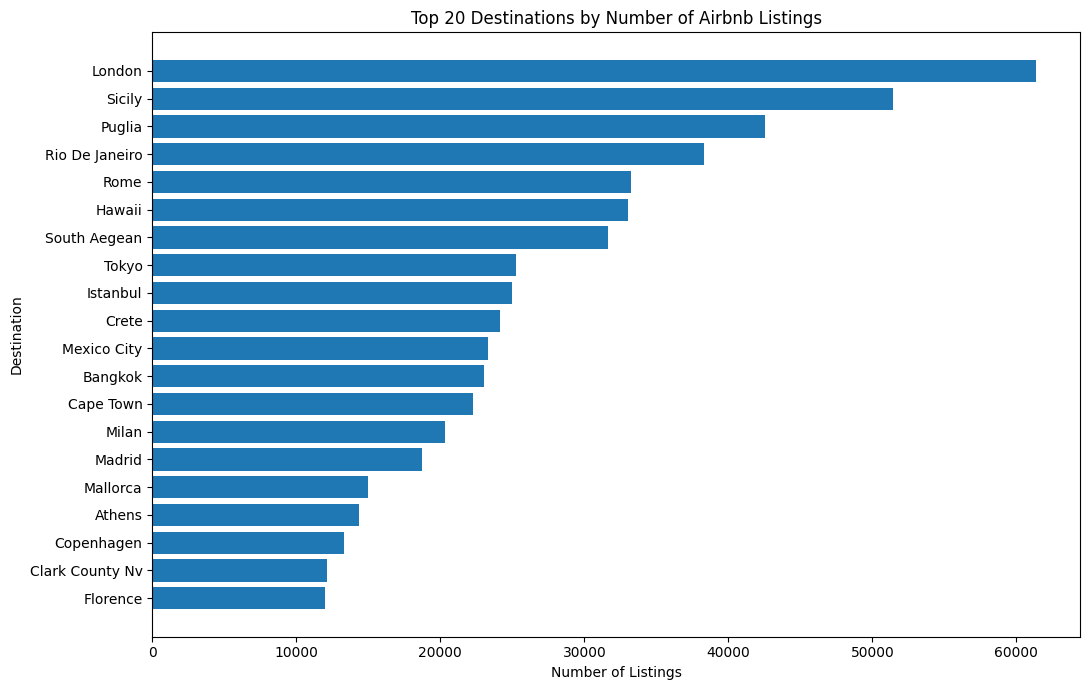

In [16]:
plt.figure(figsize=(11, 7))
plt.barh(
    top_listing_destinations["destination"].astype(str),
    top_listing_destinations["listing_count"]
)
plt.xlabel("Number of Listings")
plt.ylabel("Destination")
plt.title("Top 20 Destinations by Number of Airbnb Listings")
plt.gca().invert_yaxis()
save_plot("plot_top_20_destinations_by_listing_count.png")

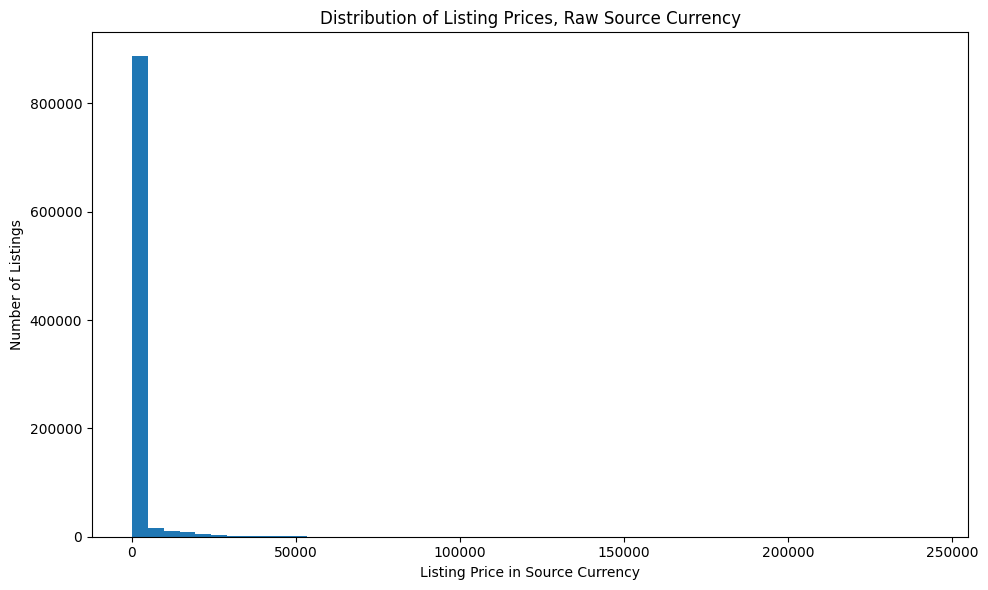

In [17]:
plt.figure(figsize=(10, 6))
plt.hist(airbnb_clean["price"], bins=50)
plt.xlabel("Listing Price in Source Currency")
plt.ylabel("Number of Listings")
plt.title("Distribution of Listing Prices, Raw Source Currency")
save_plot("plot_listing_price_distribution_raw_currency.png")

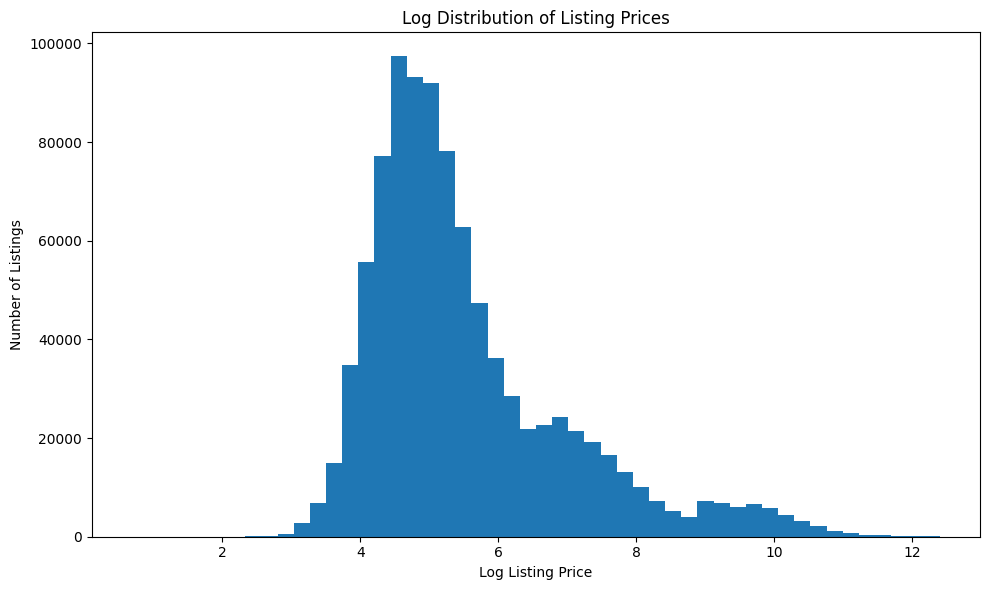

In [18]:
plt.figure(figsize=(10, 6))
plt.hist(np.log1p(airbnb_clean["price"]), bins=50)
plt.xlabel("Log Listing Price")
plt.ylabel("Number of Listings")
plt.title("Log Distribution of Listing Prices")
save_plot("plot_listing_price_log_distribution.png")

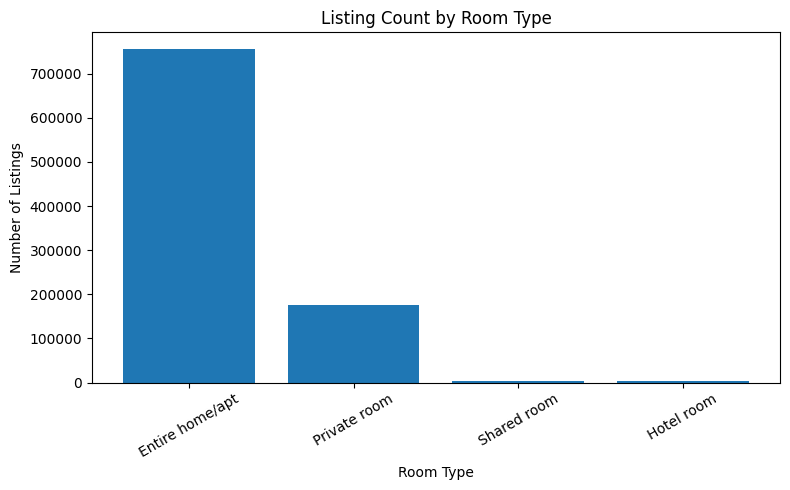

In [19]:
if not room_type_overall.empty:
    plt.figure(figsize=(8, 5))
    plt.bar(
        room_type_overall["room_type"].astype(str),
        room_type_overall["listing_count"]
    )
    plt.xlabel("Room Type")
    plt.ylabel("Number of Listings")
    plt.title("Listing Count by Room Type")
    plt.xticks(rotation=30)
    save_plot("plot_listing_count_by_room_type.png")
else:
    print("No room type data available.")

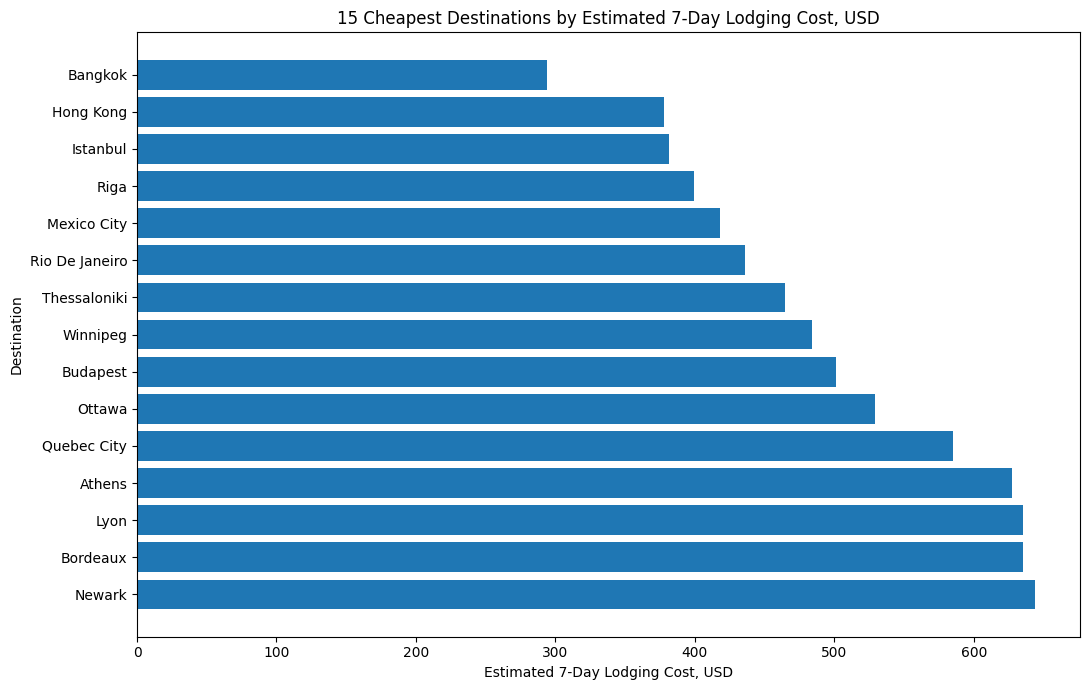

In [20]:
if "usd_ready" in globals() and not usd_ready.empty:
    cheapest_15_usd = usd_ready.nsmallest(15, "estimated_7_day_lodging_cost_usd")

    plt.figure(figsize=(11, 7))
    plt.barh(
        cheapest_15_usd["destination"].astype(str),
        cheapest_15_usd["estimated_7_day_lodging_cost_usd"]
    )
    plt.xlabel("Estimated 7-Day Lodging Cost, USD")
    plt.ylabel("Destination")
    plt.title("15 Cheapest Destinations by Estimated 7-Day Lodging Cost, USD")
    plt.gca().invert_yaxis()
    save_plot("plot_cheapest_15_destinations_usd.png")
else:
    print("USD-ready data is not available. Run the currency conversion cell first.")

In [21]:
numeric_cols = [
    "listing_count",
    "avg_airbnb_price",
    "median_airbnb_price",
    "avg_minimum_nights",
    "avg_number_of_reviews",
    "total_reviews",
    "avg_reviews_per_month",
    "avg_availability_365",
    "estimated_7_day_lodging_cost",
    "median_airbnb_price_usd",
    "avg_airbnb_price_usd",
    "estimated_7_day_lodging_cost_usd"
]

available_numeric_cols = [
    col for col in numeric_cols
    if col in airbnb_summary_global.columns
]

correlation_table = airbnb_summary_global[available_numeric_cols].corr()

correlation_table.to_csv(OUTPUT_DIR / "inside_airbnb_correlation_table.csv")

correlation_table

,listing_count,avg_airbnb_price,median_airbnb_price,avg_minimum_nights,avg_number_of_reviews,total_reviews,avg_reviews_per_month,avg_availability_365,estimated_7_day_lodging_cost,median_airbnb_price_usd,avg_airbnb_price_usd,estimated_7_day_lodging_cost_usd
listing_count,1.000000,0.121496,0.121424,-0.079073,-0.387398,0.792571,-0.372584,-0.012474,0.121424,-0.120378,-0.022846,-0.120378
avg_airbnb_price,0.121496,1.000000,0.996057,-0.050314,0.036497,0.215397,0.075469,-0.185206,0.996057,-0.152694,0.003373,-0.152694
median_airbnb_price,0.121424,0.996057,1.000000,-0.045194,0.044112,0.221064,0.097632,-0.180965,1.000000,-0.173190,-0.074269,-0.173190
avg_minimum_nights,-0.079073,-0.050314,-0.045194,1.000000,-0.150424,-0.179665,-0.088145,0.428043,-0.045194,-0.141915,-0.095040,-0.141915
avg_number_of_reviews,-0.387398,0.036497,0.044112,-0.150424,1.000000,0.052932,0.799003,-0.038549,0.044112,0.167633,-0.095846,0.167633
total_reviews,0.792571,0.215397,0.221064,-0.179665,0.052932,1.000000,0.035691,-0.059668,0.221064,-0.067886,-0.094954,-0.067886
avg_reviews_per_month,-0.372584,0.075469,0.097632,-0.088145,0.799003,0.035691,1.000000,-0.010308,0.097632,-0.182736,-0.287842,-0.182736
avg_availability_365,-0.012474,-0.185206,-0.180965,0.428043,-0.038549,-0.059668,-0.010308,1.000000,-0.180965,-0.294625,-0.186716,-0.294625
estimated_7_day_lodging_cost,0.121424,0.996057,1.000000,-0.045194,0.044112,0.221064,0.097632,-0.180965,1.000000,-0.173190,-0.074269,-0.173190
median_airbnb_price_usd,-0.120378,-0.152694,-0.173190,-0.141915,0.167633,-0.067886,-0.182736,-0.294625,-0.173190,1.000000,0.472772,1.000000


In [22]:
merge_cols = [
    "location_path",
    "destination",
    "country",
    "region",
    "listing_count",
    "median_airbnb_price",
    "avg_airbnb_price",
    "estimated_7_day_lodging_cost",
    "currency",
    "usd_rate",
    "median_airbnb_price_usd",
    "avg_airbnb_price_usd",
    "estimated_7_day_lodging_cost_usd",
    "avg_number_of_reviews",
    "avg_reviews_per_month",
    "avg_availability_365"
]

merge_cols = [col for col in merge_cols if col in airbnb_summary_global.columns]

accommodation_merge_ready_global = airbnb_summary_global[merge_cols].copy()

accommodation_merge_ready_global.to_csv(
    OUTPUT_DIR / "accommodation_merge_ready_global.csv",
    index=False
)

print("Saved merge-ready file:")
print(OUTPUT_DIR / "accommodation_merge_ready_global.csv")

accommodation_merge_ready_global.head(20)

Saved merge-ready file:
inside_airbnb_outputs/accommodation_merge_ready_global.csv


,location_path,destination,country,region,listing_count,median_airbnb_price,avg_airbnb_price,estimated_7_day_lodging_cost,currency,usd_rate,median_airbnb_price_usd,avg_airbnb_price_usd,estimated_7_day_lodging_cost_usd,avg_number_of_reviews,avg_reviews_per_month,avg_availability_365
4,australia/tas/tasmania,Tasmania,Australia,Tas,5609,197.0,227.789446,1379.0,AUD,0.71407,140.671790,162.657609,984.702530,101.783562,2.097261,228.086825
7,australia/wa/western-australia,Western Australia,Australia,Wa,11141,218.0,255.928193,1526.0,AUD,0.71407,155.667260,182.750645,1089.670820,61.682793,1.743817,222.521407
0,australia/nsw/mid-north-coast,Mid North Coast,Australia,Nsw,4572,249.0,292.925416,1743.0,AUD,0.71407,177.803430,209.169251,1244.624010,53.765967,1.315658,240.729440
5,australia/vic/barwon-south-west-vic,Barwon South West Vic,Australia,Vic,6245,296.0,351.034107,2072.0,AUD,0.71407,211.364720,250.662925,1479.553040,62.725060,1.365126,210.247878
3,australia/sa/barossa-valley,Barossa Valley,Australia,Sa,314,303.5,365.624204,2124.5,AUD,0.71407,216.720245,261.081275,1517.041715,65.277070,1.493262,267.076433
1,australia/nsw/northern-rivers,Northern Rivers,Australia,Nsw,5354,334.0,461.583489,2338.0,AUD,0.71407,238.499380,329.602922,1669.495660,53.102167,1.231715,217.916698
2,australia/qld/sunshine-coast,Sunshine Coast,Australia,Qld,6395,351.0,453.965598,2457.0,AUD,0.71407,250.638570,324.163215,1754.469990,54.867553,1.540034,206.142768
6,australia/vic/mornington-peninsula,Mornington Peninsula,Australia,Vic,3999,392.0,500.378095,2744.0,AUD,0.71407,279.915440,357.304986,1959.408080,48.000250,1.204664,245.945236
8,austria/vienna/vienna,Vienna,Austria,Vienna,10202,92.0,116.203980,644.0,EUR,1.16400,107.088000,135.261432,749.616000,51.842090,1.824123,212.689865
9,belgium/bru/brussels,Brussels,Belgium,Bru,5014,90.0,107.771440,630.0,EUR,1.16400,104.760000,125.445956,733.320000,57.041085,2.216260,208.343638


In [23]:
print("Files saved in:", OUTPUT_DIR.resolve())

for file in sorted(OUTPUT_DIR.iterdir()):
    print(file.name)

Files saved in: /content/inside_airbnb_outputs
accommodation_merge_ready_global.csv
currency_rates_to_usd.csv
inside_airbnb_accommodation_clean.csv
inside_airbnb_cheapest_20_destinations_raw_currency.csv
inside_airbnb_cheapest_20_destinations_usd.csv
inside_airbnb_correlation_table.csv
inside_airbnb_country_summary.csv
inside_airbnb_expensive_20_destinations_raw_currency.csv
inside_airbnb_expensive_20_destinations_usd.csv
inside_airbnb_failed_downloads.csv
inside_airbnb_global_destination_summary.csv
inside_airbnb_global_destination_summary_with_usd.csv
inside_airbnb_quality_summary.csv
inside_airbnb_raw_combined.csv
inside_airbnb_room_type_overall.csv
inside_airbnb_room_type_summary.csv
inside_airbnb_selected_source_links.csv
inside_airbnb_top_20_listing_destinations.csv
inside_airbnb_view_table.csv
plot_cheapest_15_destinations_usd.png
plot_listing_count_by_room_type.png
plot_listing_price_distribution_raw_currency.png
plot_listing_price_log_distribution.png
plot_top_20_destinations_